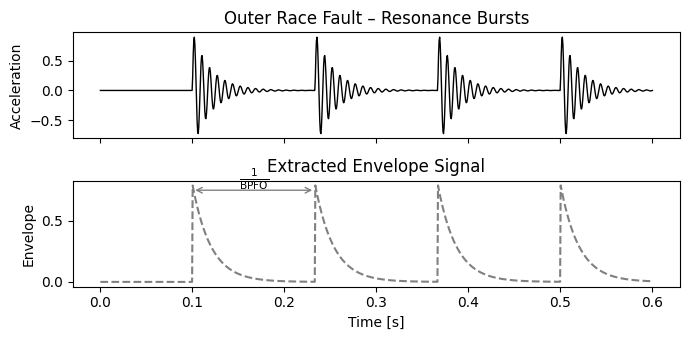

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
t = np.linspace(0, 0.6, 1000)

# Outer race: burst locations
impulse_times = np.linspace(0.1, 0.5, 4)
signal = np.zeros_like(t)

# Resonance burst function
def resonance_burst(center, t, f=120, decay=50):
    return np.exp(-decay * (t - center)) * np.sin(2 * np.pi * f * (t - center)) * (t >= center)

# Build raw signal
for ti in impulse_times:
    signal += resonance_burst(ti, t)

# Envelope (decaying pulses)
envelope = np.zeros_like(t)
for ti in impulse_times:
    envelope += 0.8 * np.exp(-50 * (t - ti)) * (t >= ti)

# Plotting with label in envelope plot
fig, ax = plt.subplots(2, 1, figsize=(7, 3.5), sharex=True)

# Top: signal
ax[0].plot(t, signal, color="black", linewidth=1)
ax[0].set_ylabel("Acceleration")
ax[0].set_title("Outer Race Fault – Resonance Bursts")

# Bottom: envelope with annotation
ax[1].plot(t, envelope, color="gray", linestyle="--", linewidth=1.5)
ax[1].set_ylabel("Envelope")
ax[1].set_xlabel("Time [s]")
ax[1].set_title("Extracted Envelope Signal")

# Annotate 1/BPFO in envelope
x1 = impulse_times[0]
x2 = impulse_times[1]
y = 0.75
ax[1].annotate('', xy=(x1, y), xytext=(x2, y),
               arrowprops=dict(arrowstyle='<->', color='gray'))
ax[1].text((x1+x2)/2, y+0.05, r"$\frac{1}{\mathrm{BPFO}}$", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


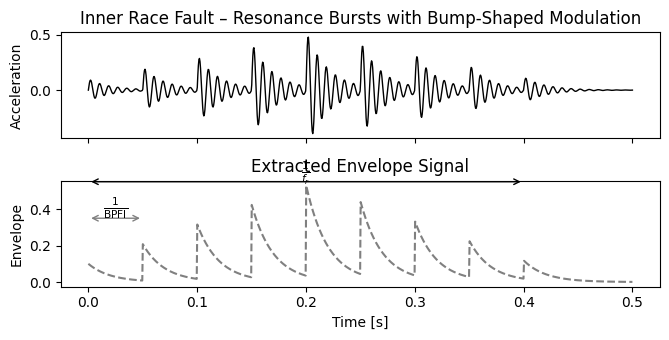

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis starting at 0 (more compact)
t = np.linspace(0, 0.5, 1000)
impulse_times = np.linspace(0.0, 0.4, 9)
amplitudes = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1]) * 0.1

# Parameters
res_freq = 120
decay = 50

# Initialize signals
signal = np.zeros_like(t)
envelope = np.zeros_like(t)

# Resonance burst function
def resonance_burst(center, t, f=120, decay=50):
    return np.exp(-decay * (t - center)) * np.sin(2 * np.pi * f * (t - center)) * (t >= center)

# Construct signal and envelope
for ti, ai in zip(impulse_times, amplitudes):
    signal += ai * resonance_burst(ti, t, f=res_freq, decay=decay)
    envelope += ai * np.exp(-decay * (t - ti)) * (t >= ti)

# Plot
fig, ax = plt.subplots(2, 1, figsize=(7, 3.5), sharex=True)

# Plot raw signal
ax[0].plot(t, signal, color="black", linewidth=1)
ax[0].set_ylabel("Acceleration")
ax[0].set_title("Inner Race Fault – Resonance Bursts with Bump-Shaped Modulation")

# Plot envelope signal
ax[1].plot(t, envelope, color="gray", linestyle="--", linewidth=1.5)
ax[1].set_ylabel("Envelope")
ax[1].set_xlabel("Time [s]")
ax[1].set_title("Extracted Envelope Signal")

# Annotate 1/BPFI (positioned close to envelope spikes)
x1 = impulse_times[0]
x2 = impulse_times[1]
y_bpf = 0.35
ax[1].annotate('', xy=(x1, y_bpf), xytext=(x2, y_bpf),
               arrowprops=dict(arrowstyle='<->', color='gray'))
ax[1].text((x1 + x2) / 2, y_bpf + 0.03, r"$\frac{1}{\mathrm{BPFI}}$", ha='center', fontsize=11)

# Annotate 1/fr (over full modulation cycle, but with more vertical space)
x_fr1 = impulse_times[0]
x_fr2 = impulse_times[-1]
y_fr = 0.55
ax[1].annotate('', xy=(x_fr1, y_fr), xytext=(x_fr2, y_fr),
               arrowprops=dict(arrowstyle='<->', color='black'))
ax[1].text((x_fr1 + x_fr2) / 2, y_fr + 0.03, r"$\frac{1}{f_r}$", ha='center', fontsize=11)

plt.tight_layout()
plt.show()
